In [1]:
# Step 0: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Iris Dataset from Scikit-learn
iris = load_iris()
# For visual boundary plotting later, we use the first two features: Sepal Length & Sepal Width
X = pd.DataFrame(iris['data'][:, :2], columns=iris['feature_names'][:2])
y = iris['target']

print("--- Step 1: Dataset Loaded Successfully ---")
print(f"Dataset Features Shape (using 2 features for plotting): {X.shape[0]} rows, {X.shape[1]} columns.\n")

--- Step 1: Dataset Loaded Successfully ---
Dataset Features Shape (using 2 features for plotting): 150 rows, 2 columns.



In [2]:
# 2. Split data into training and testing sets
# 80% Training data, 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# 3. Scale features (Highly critical for SVM since it is a distance-based boundary estimator)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- Step 2: Data Split & Feature Scaling Complete ---\n")

--- Step 2: Data Split & Feature Scaling Complete ---



In [4]:
# 4. Implement Linear and RBF Kernels
print("--- Step 3: Training SVM Models with Different Kernels ---")

# Model A: Linear Kernel SVM
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)
linear_pred = linear_svm.predict(X_test_scaled)
linear_acc = accuracy_score(y_test, linear_pred)
print(f"Linear Kernel Model Trained. Test Accuracy: {linear_acc * 100:.2f}%")

# Model B: Radial Basis Function (RBF) Kernel SVM
rbf_svm = SVC(kernel='rbf', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
rbf_pred = rbf_svm.predict(X_test_scaled)
rbf_acc = rbf_svm.aggregate if hasattr(rbf_svm, 'aggregate') else accuracy_score(y_test, rbf_pred)
print(f"RBF Kernel Model Trained. Test Accuracy: {rbf_acc * 100:.2f}%\n")

--- Step 3: Training SVM Models with Different Kernels ---
Linear Kernel Model Trained. Test Accuracy: 90.00%
RBF Kernel Model Trained. Test Accuracy: 83.33%



In [5]:
# 5. Evaluate and save the Kernel Comparison Report
print("--- Step 4: Generating Kernel Comparison Report ---")
with open("kernel_comparison_report.txt", "w") as f:
    f.write("=== SVM KERNEL PERFORMANCE COMPARISON REPORT ===\n\n")
    f.write(f"Linear Kernel Accuracy: {linear_acc * 100:.2f}%\n")
    f.write(f"RBF Kernel Accuracy   : {rbf_acc * 100:.2f}%\n\n")
    f.write("=== LINEAR KERNEL CLASSIFICATION REPORT ===\n")
    f.write(classification_report(y_test, linear_pred, target_names=iris['target_names']))
    f.write("\n=== RBF KERNEL CLASSIFICATION REPORT ===\n")
    f.write(classification_report(y_test, rbf_pred, target_names=iris['target_names']))
print("Success! 'kernel_comparison_report.txt' saved locally.\n")

--- Step 4: Generating Kernel Comparison Report ---
Success! 'kernel_comparison_report.txt' saved locally.



Success! 'svm_confusion_matrices.png' saved locally.


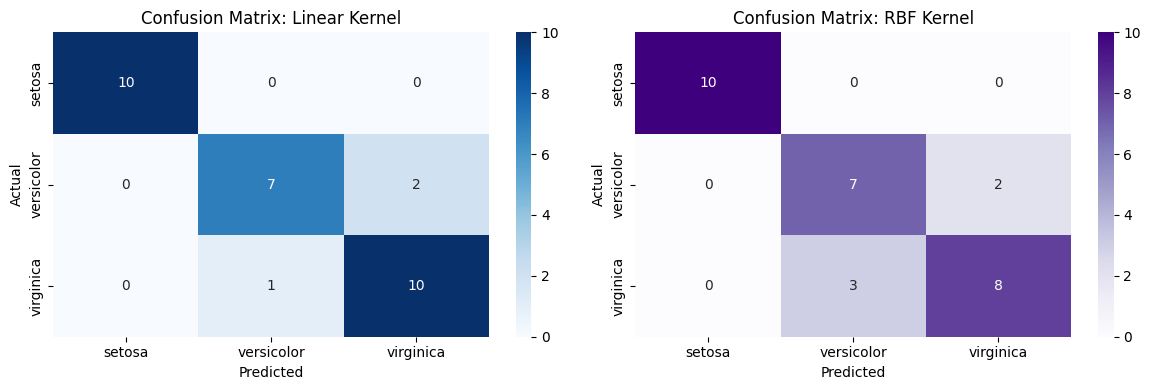

In [6]:
# 6. Evaluate with a Confusion Matrix Visual
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

cm_linear = confusion_matrix(y_test, linear_pred)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=iris['target_names'], yticklabels=iris['target_names'])
ax[0].set_title('Confusion Matrix: Linear Kernel')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

cm_rbf = confusion_matrix(y_test, rbf_pred)
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Purples', ax=ax[1],
            xticklabels=iris['target_names'], yticklabels=iris['target_names'])
ax[1].set_title('Confusion Matrix: RBF Kernel')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('svm_confusion_matrices.png', dpi=300)
print("Success! 'svm_confusion_matrices.png' saved locally.")
plt.show()

Success! 'svm_decision_boundaries.png' saved locally.


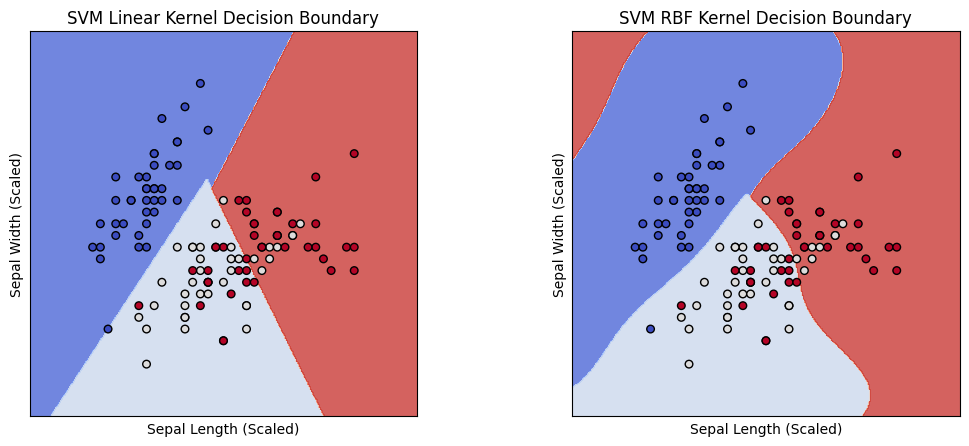

In [7]:
# 7. Helper Function to Plot Decision Boundaries
def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# Set up mesh grids for plotting decision boundaries
fig, sub = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X_train_scaled[:, 0], X_train_scaled[:, 1]
x_min, x_max = X0.min() - 1, X0.max() + 1
y_min, y_max = X1.min() - 1, X1.max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

titles = ('SVM Linear Kernel Decision Boundary', 'SVM RBF Kernel Decision Boundary')
models = (linear_svm, rbf_svm)

for clf, title, ax in zip(models, titles, sub.flatten()):
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    scatter = ax.scatter(X0, X1, c=y_train, cmap=plt.cm.coolwarm, s=30, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Sepal Length (Scaled)')
    ax.set_ylabel('Sepal Width (Scaled)')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.savefig('svm_decision_boundaries.png', dpi=300, bbox_inches='tight')
print("Success! 'svm_decision_boundaries.png' saved locally.")
plt.show()